# Credit Score Classification — Data Exploration & Modelling

**Konteks:** Sebagai data scientist di institusi keuangan, kita membangun model
machine learning untuk menilai performa kredit setiap nasabah. Target
`Credit_Score` memiliki **tiga kelas**: **Poor**, **Standard**, **Good**.

Isi notebook:
1. Pemuatan & pemahaman data
2. Pembersihan data (dataset ini terkenal "kotor")
3. Exploratory Data Analysis (EDA)
4. Preprocessing
5. Eksperimen beberapa model + evaluasi
6. Pemilihan model terbaik


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

df_raw = pd.read_csv("data_A.csv")
print("Ukuran data mentah:", df_raw.shape)
df_raw.head()

Ukuran data mentah: (25000, 29)


,Unnamed: 0,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0,0xa658,CUS_0x936d,March,Alistair Barrs,8466,703-48-3482,_______,100433.58,8074.465000,1,5,10,2,"Student Loan, and Debt Consolidation Loan",13,4,12.59,3.0,Good,1023.93,33.471395,20 Years and 5 Months,No,100.163466,758.0704866746678,Low_spent_Medium_value_payments,229.21254743638283,Standard
1,1,0x6739,CUS_0x9a29,August,Phila,25,339-28-0072,Developer,33119.82,3024.985000,10,5,32,5,"Home Equity Loan, Mortgage Loan, Home Equity L...",50,18,15.79,10.0,Bad,2545.0,33.810567,14 Years and 8 Months,Yes,111.422702,NaN,Low_spent_Small_value_payments,370.6074980582689,Poor
2,2,0xdcf5,CUS_0x12a9,April,Driverb,44,583-20-9758,_______,44822.21,3555.184167,1,4,2,4,"Credit-Builder Loan, Debt Consolidation Loan, ...",14,8,4.03,0.0,Good,730.64,31.145739,23 Years and 10 Months,NM,135.044286,256.4742969677053,Low_spent_Medium_value_payments,243.99983412342044,Standard
3,3,0x14453,CUS_0x3bad,June,Prasadc,29,510-25-2095,Musician,142081.48,11771.123333,6,6,15,3_,"Personal Loan, Not Specified, and Mortgage Loan",29,20,8.21,4.0,Standard,932.32,28.409526,27 Years and 0 Months,No,180.616478,423.96126196668365,Low_spent_Small_value_payments,862.534593039876,Standard
4,4,0x1198e,CUS_0xa3e1,January,Poornimai,45,943-92-4350,Scientist,19267.27_,1374.605833,10,8,25,6,"Home Equity Loan, Auto Loan, Payday Loan, Not ...",33,NaN,19.7,6.0,Bad,3777.55,28.373426,10 Years and 3 Months,Yes,78.954825,133.56850235207634,Low_spent_Small_value_payments,214.93725572483646,Poor


## 1. Pemahaman Data

Dataset berisi 1 baris per nasabah per bulan. Banyak kolom numerik tersimpan
sebagai teks dengan karakter sampah (mis. `'19267.27_'`), placeholder tak valid
(`'_______'`, `'_'`, `'!@9#%8'`), dan outlier ekstrem (mis. `Age = 8466`).

In [2]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                25000 non-null  int64  
 1   ID                        25000 non-null  object 
 2   Customer_ID               25000 non-null  object 
 3   Month                     25000 non-null  object 
 4   Name                      22440 non-null  object 
 5   Age                       25000 non-null  object 
 6   SSN                       25000 non-null  object 
 7   Occupation                25000 non-null  object 
 8   Annual_Income             25000 non-null  object 
 9   Monthly_Inhand_Salary     21417 non-null  float64
 10  Num_Bank_Accounts         25000 non-null  int64  
 11  Num_Credit_Card           25000 non-null  int64  
 12  Interest_Rate             25000 non-null  int64  
 13  Num_of_Loan               25000 non-null  object 
 14  Type_o

### 1.1 Distribusi target (3 kelas)

Credit_Score
Standard    13330
Poor         7302
Good         4368
Name: count, dtype: int64


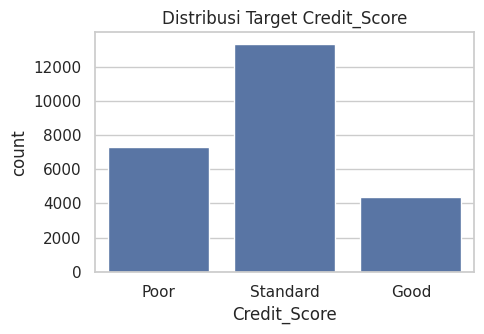

In [3]:
print(df_raw["Credit_Score"].value_counts())
fig, ax = plt.subplots(figsize=(5, 3.5))
sns.countplot(x="Credit_Score", data=df_raw,
              order=["Poor", "Standard", "Good"], ax=ax)
ax.set_title("Distribusi Target Credit_Score")
plt.tight_layout(); plt.show()

> Kelas tidak seimbang (Standard paling banyak, Good paling sedikit). Karena
> itu kita memakai penyeimbang kelas saat training dan menilai model dengan
> **F1-macro / recall-macro / ROC-AUC (OvR)**, bukan hanya accuracy.

### 1.2 Contoh kolom 'kotor' yang perlu dibersihkan

In [4]:
for c in ["Age", "Annual_Income", "Occupation", "Credit_Mix",
          "Payment_Behaviour", "Credit_History_Age"]:
    print(f"{c:<20}:", list(pd.Series(df_raw[c].astype(str).unique()).head(5)))

Age                 : ['8466', '25', '44', '29', '45']
Annual_Income       : ['100433.58', '33119.82', '44822.21', '142081.48', '19267.27_']
Occupation          : ['_______', 'Developer', 'Musician', 'Scientist', 'Entrepreneur']
Credit_Mix          : ['Good', 'Bad', 'Standard', '_']
Payment_Behaviour   : ['Low_spent_Medium_value_payments', 'Low_spent_Small_value_payments', 'High_spent_Large_value_payments', 'Low_spent_Large_value_payments', '!@9#%8']


Credit_History_Age  : ['20 Years and 5 Months', '14 Years and 8 Months', '23 Years and 10 Months', '27 Years and 0 Months', '10 Years and 3 Months']


## 2. Pembersihan Data

Seluruh logika pembersihan ada di modul `data_cleaning.py` (dipakai ulang oleh
pipeline). Ringkasan langkah:
- Kolom numerik: buang karakter non-angka, cast ke float, buang outlier di luar
  batas domain wajar (jadikan NaN untuk diimputasi).
- `Credit_History_Age` `'X Years and Y Months'` -> total bulan (numerik).
- `Type_of_Loan` -> jumlah jenis pinjaman (`Num_Loan_Types`).
- Placeholder kategorikal (`'_______'`, `'_'`, `'!@9#%8'`, `'NM'`) -> NaN.
- Kolom identitas/PII (`ID`, `Customer_ID`, `Name`, `SSN`, dll.) -> dibuang.

In [5]:
from data_cleaning import clean_dataframe, NUMERIC_FEATURES, CATEGORICAL_FEATURES

df = clean_dataframe(df_raw)
print("Setelah cleaning:", df.shape)
print("Fitur numerik   :", len(NUMERIC_FEATURES))
print("Fitur kategorikal:", len(CATEGORICAL_FEATURES))
df[NUMERIC_FEATURES].describe().T[["mean", "min", "max"]].round(2)

Setelah cleaning: (25000, 23)
Fitur numerik   : 18
Fitur kategorikal: 4


,mean,min,max
Age,33.24,14.00,95.00
Annual_Income,50677.66,7005.93,475717.00
Monthly_Inhand_Salary,4215.67,303.65,15167.18
Num_Bank_Accounts,5.38,0.00,11.00
Num_Credit_Card,5.54,0.00,15.00
Interest_Rate,14.58,1.00,34.00
Num_of_Loan,3.56,0.00,9.00
Delay_from_due_date,21.19,-5.00,67.00
Num_of_Delayed_Payment,13.46,0.00,28.00
Changed_Credit_Limit,10.38,-6.43,36.29


### 2.1 Missing value setelah cleaning (akan diimputasi di pipeline)

In [6]:
m = df.isna().sum()
m[m > 0].sort_values(ascending=False)

Credit_Mix                 5066
Monthly_Inhand_Salary      3583
Payment_of_Min_Amount      3000
Credit_History_Months      2249
Num_of_Delayed_Payment     2070
Payment_Behaviour          1852
Occupation                 1770
Amount_invested_monthly    1164
Num_of_Loan                1089
Num_Credit_Inquiries        923
Age                         666
Num_Credit_Card             563
Changed_Credit_Limit        518
Interest_Rate               479
Num_Bank_Accounts           339
Monthly_Balance             293
Annual_Income               262
dtype: int64

## 3. Exploratory Data Analysis (EDA)

### 3.1 Distribusi beberapa fitur numerik penting

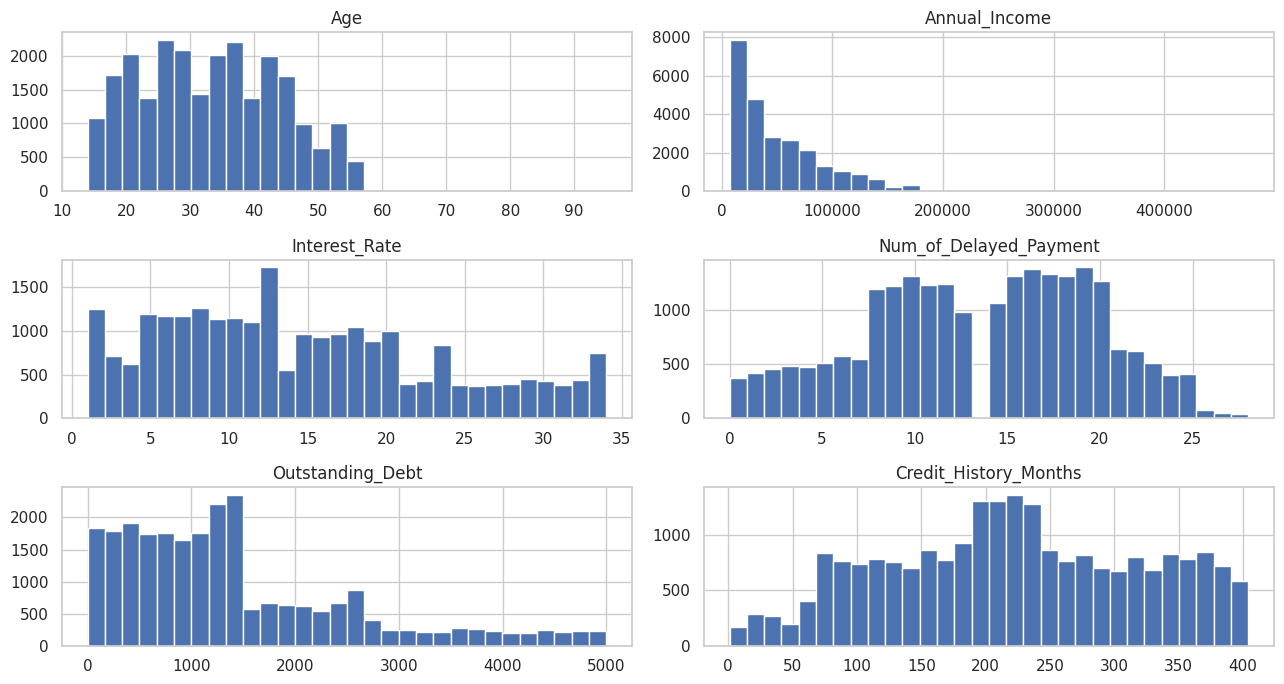

In [7]:
cols = ["Age", "Annual_Income", "Interest_Rate", "Num_of_Delayed_Payment",
        "Outstanding_Debt", "Credit_History_Months"]
df[cols].hist(figsize=(13, 7), bins=30)
plt.tight_layout(); plt.show()

### 3.2 Fitur numerik terhadap kelas credit score

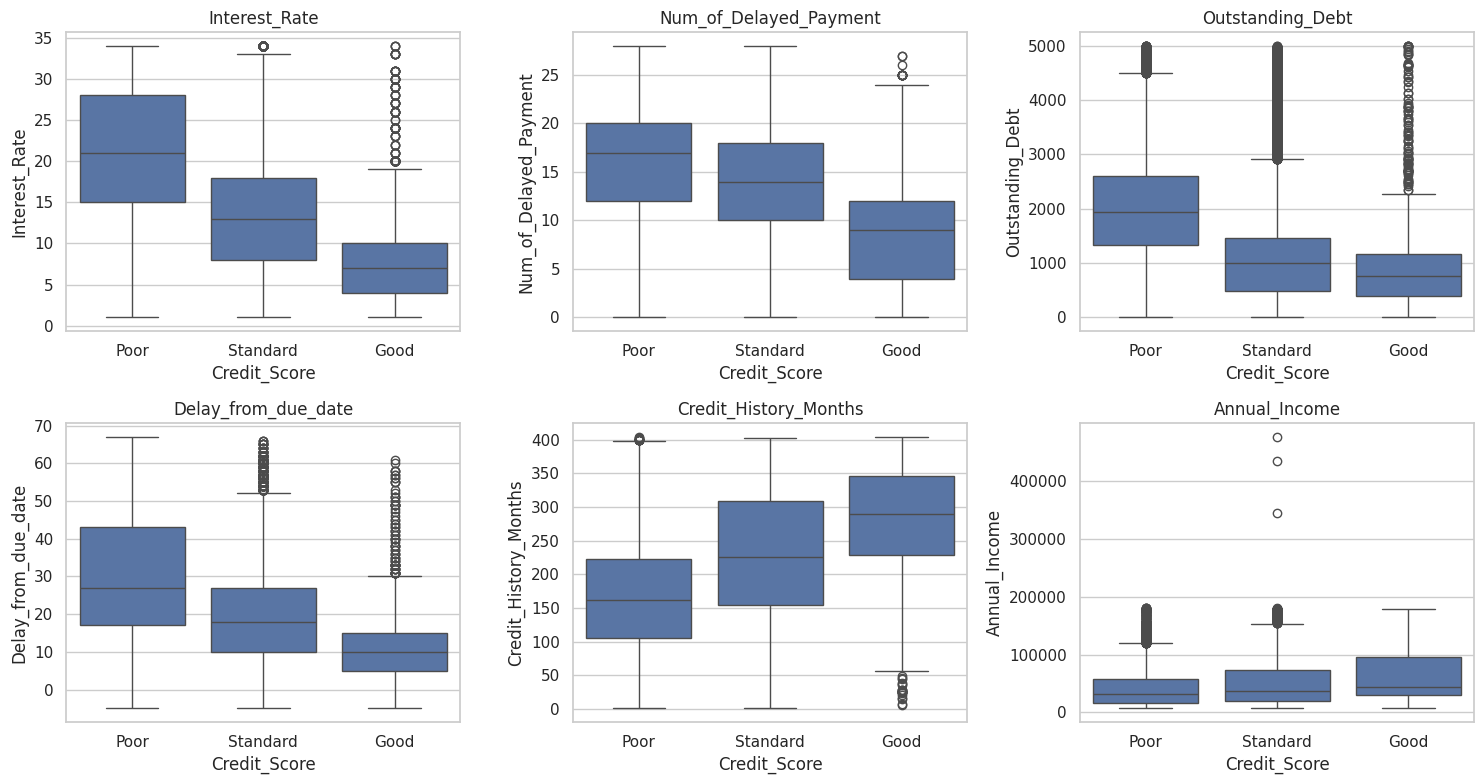

In [8]:
order = ["Poor", "Standard", "Good"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
tmp = df.copy(); tmp["Credit_Score"] = df_raw["Credit_Score"]
for ax, col in zip(axes.ravel(),
                   ["Interest_Rate", "Num_of_Delayed_Payment", "Outstanding_Debt",
                    "Delay_from_due_date", "Credit_History_Months", "Annual_Income"]):
    sns.boxplot(x="Credit_Score", y=col, data=tmp, order=order, ax=ax)
    ax.set_title(col)
plt.tight_layout(); plt.show()

**Insight:** kelas **Poor** cenderung punya suku bunga, jumlah keterlambatan,
dan outstanding debt lebih tinggi, serta riwayat kredit lebih pendek — konsisten
dengan intuisi risiko.

### 3.3 Fitur kategorikal terhadap kelas

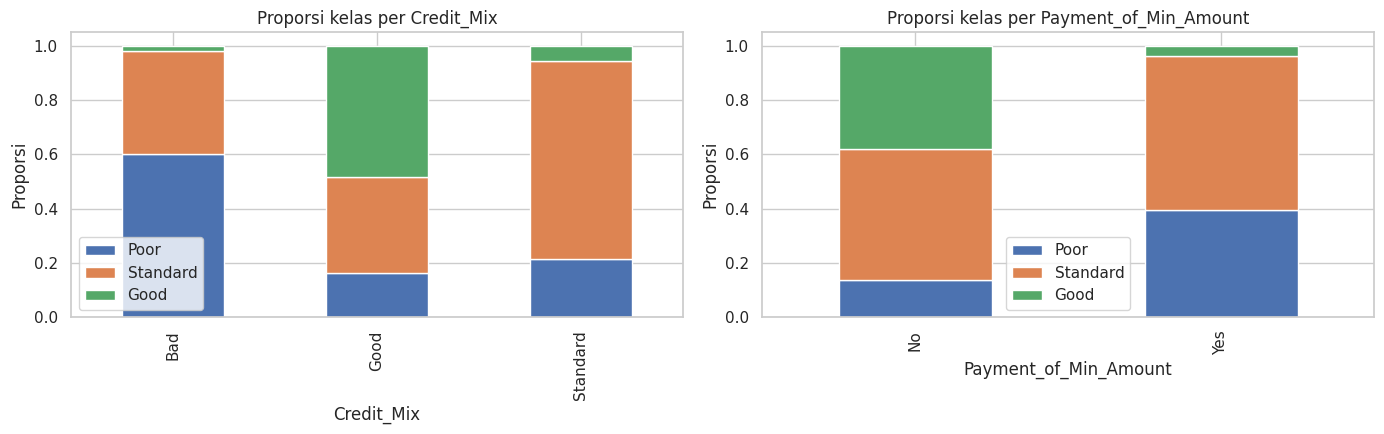

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, col in zip(axes, ["Credit_Mix", "Payment_of_Min_Amount"]):
    ct = pd.crosstab(tmp[col], tmp["Credit_Score"], normalize="index")[order]
    ct.plot(kind="bar", stacked=True, ax=ax)
    ax.set_title(f"Proporsi kelas per {col}"); ax.legend(title="")
    ax.set_ylabel("Proporsi")
plt.tight_layout(); plt.show()

### 3.4 Korelasi antar fitur numerik

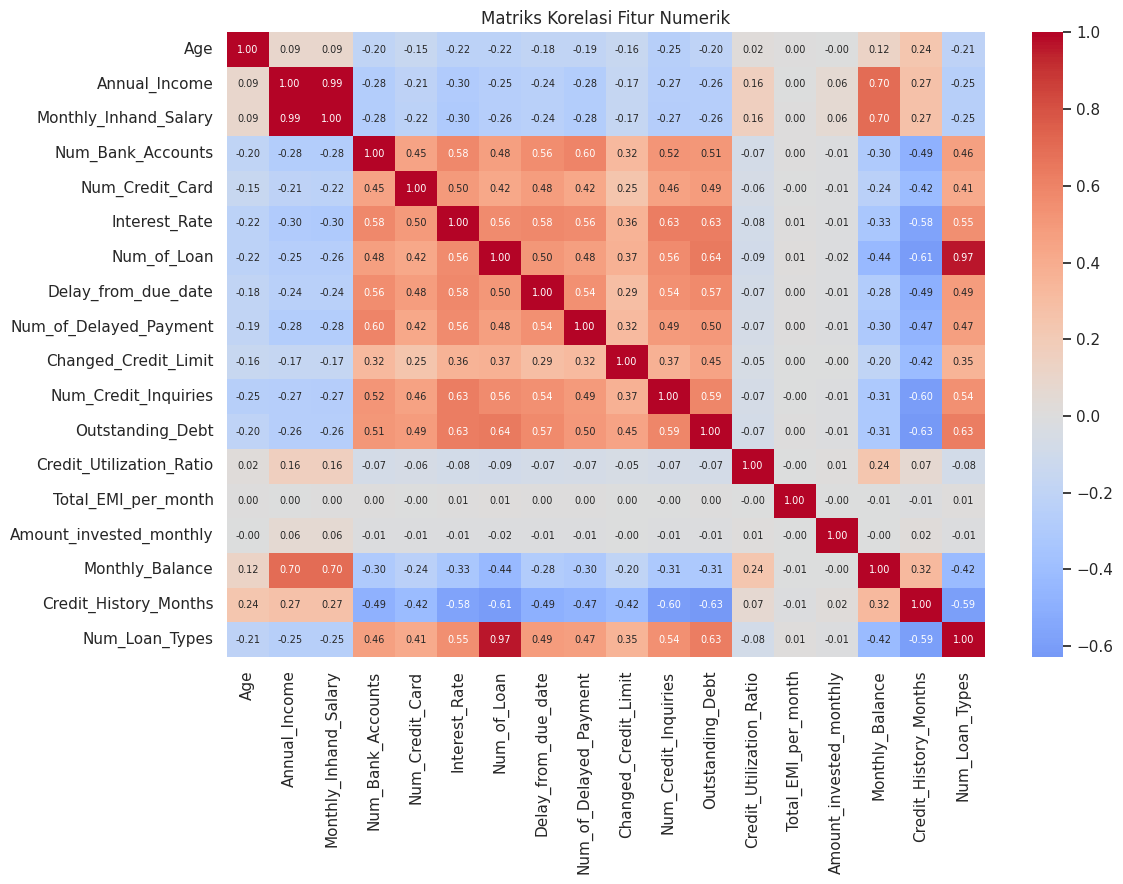

In [10]:
fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(df[NUMERIC_FEATURES].corr(), annot=True, fmt=".2f",
            cmap="coolwarm", center=0, annot_kws={"size": 7}, ax=ax)
plt.title("Matriks Korelasi Fitur Numerik"); plt.tight_layout(); plt.show()

## 4. Preprocessing

Diterapkan di dalam Pipeline (lihat `pipeline.py`) agar fit hanya pada data train
(mencegah data leakage) dan ikut tersimpan dalam `.pkl`:

| Jenis | Imputasi | Transformasi |
|-------|----------|--------------|
| Numerik | median | StandardScaler |
| Kategorikal | modus | OneHotEncoder |


## 5. Eksperimen Model Machine Learning

Tiga model dibandingkan: **Logistic Regression**, **Random Forest**, dan
**XGBoost**, semuanya dengan penyeimbang kelas. Target di-encode ke 0/1/2.

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, f1_score, recall_score,
                             precision_score, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay)

X = df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = df_raw["Credit_Score"].astype(str)
le = LabelEncoder(); y_enc = le.fit_transform(y)
classes = list(le.classes_)

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc)

def make_prep():
    num = Pipeline([("imp", SimpleImputer(strategy="median")),
                    ("sc", StandardScaler())])
    cat = Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                    ("oh", OneHotEncoder(handle_unknown="ignore"))])
    return ColumnTransformer([("num", num, NUMERIC_FEATURES),
                              ("cat", cat, CATEGORICAL_FEATURES)])

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000,
                              class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=18,
                              class_weight="balanced_subsample",
                              random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(n_estimators=500, max_depth=6, learning_rate=0.05,
                              subsample=0.9, colsample_bytree=0.9,
                              eval_metric="mlogloss", random_state=42),
}
print("Kelas:", classes, "| Train:", X_tr.shape, "Test:", X_te.shape)

Kelas: ['Good', 'Poor', 'Standard'] | Train: (20000, 22) Test: (5000, 22)


In [12]:
results = []; fitted = {}
for name, est in models.items():
    pipe = Pipeline([("prep", make_prep()), ("model", est)])
    if name == "XGBoost":
        sw = compute_sample_weight("balanced", y_tr)
        pipe.fit(X_tr, y_tr, model__sample_weight=sw)
    else:
        pipe.fit(X_tr, y_tr)
    fitted[name] = pipe
    pred = pipe.predict(X_te); proba = pipe.predict_proba(X_te)
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_te, pred),
        "Precision(macro)": precision_score(y_te, pred, average="macro"),
        "Recall(macro)": recall_score(y_te, pred, average="macro"),
        "F1(macro)": f1_score(y_te, pred, average="macro"),
        "ROC-AUC(ovr)": roc_auc_score(y_te, proba, multi_class="ovr", average="macro"),
    })
res_df = pd.DataFrame(results).set_index("Model").round(3)
res_df

,Accuracy,Precision(macro),Recall(macro),F1(macro),ROC-AUC(ovr)
Model,,,,,
Logistic Regression,0.654,0.635,0.686,0.645,0.805
Random Forest,0.720,0.692,0.727,0.705,0.872
XGBoost,0.718,0.694,0.744,0.708,0.871


### 5.1 Perbandingan visual

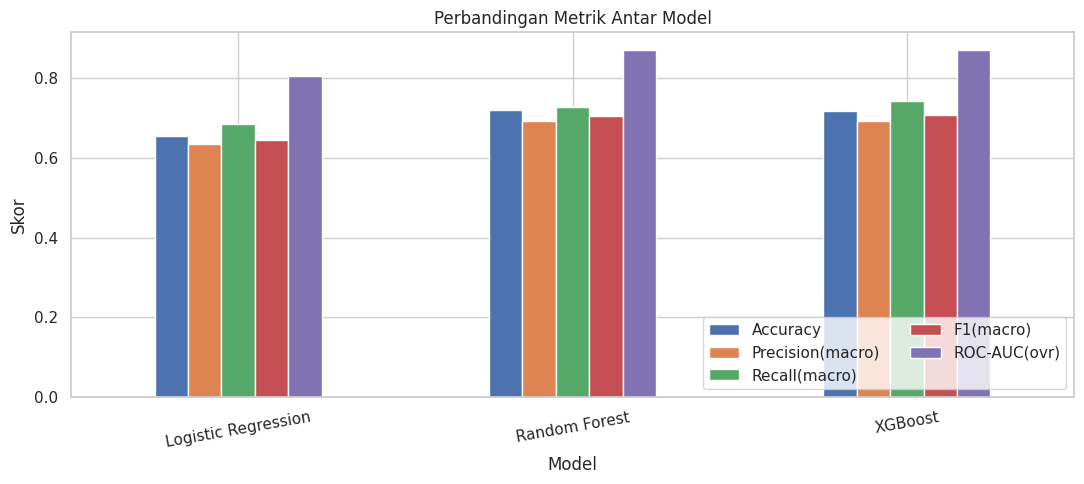

In [13]:
ax = res_df.plot(kind="bar", figsize=(11, 5))
ax.set_title("Perbandingan Metrik Antar Model"); ax.set_ylabel("Skor")
ax.legend(loc="lower right", ncol=2); plt.xticks(rotation=10)
plt.tight_layout(); plt.show()

### 5.2 Confusion matrix model terbaik

Model terbaik (F1-macro): XGBoost


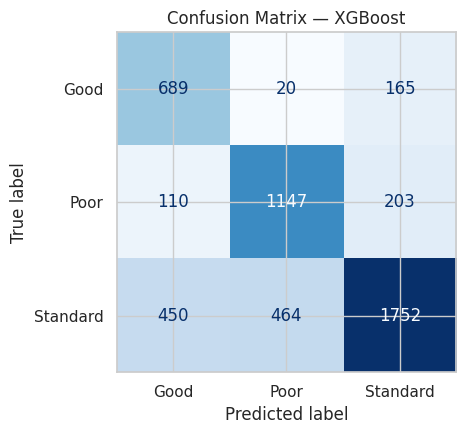

In [14]:
best_name = res_df["F1(macro)"].idxmax()
best = fitted[best_name]
print("Model terbaik (F1-macro):", best_name)
cm = confusion_matrix(y_te, best.predict(X_te))
disp = ConfusionMatrixDisplay(cm, display_labels=classes)
fig, ax = plt.subplots(figsize=(5, 4.5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Confusion Matrix — {best_name}")
plt.tight_layout(); plt.show()

### 5.3 Fitur paling berpengaruh (model terbaik)

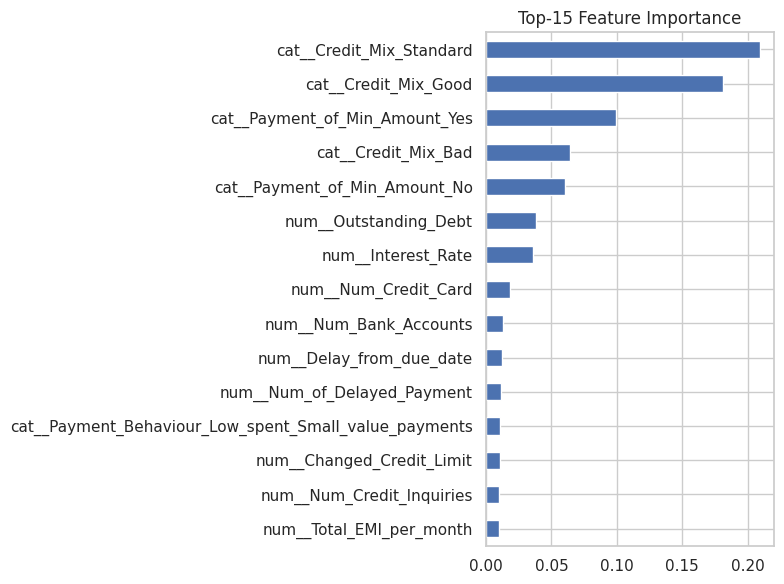

In [15]:
try:
    m = best.named_steps["model"]
    feat_names = best.named_steps["prep"].get_feature_names_out()
    if hasattr(m, "feature_importances_"):
        imp = pd.Series(m.feature_importances_, index=feat_names)
        imp.sort_values(ascending=False).head(15).plot(
            kind="barh", figsize=(8, 6))
        plt.gca().invert_yaxis(); plt.title("Top-15 Feature Importance")
        plt.tight_layout(); plt.show()
    else:
        print("Model ini tidak menyediakan feature_importances_.")
except Exception as e:
    print("Lewati:", e)

## 6. Kesimpulan & Rangkuman Eksperimen

- **Fitur:** 18 fitur numerik (usia, income, gaji, jumlah akun/kartu, suku bunga,
  jumlah & jenis pinjaman, keterlambatan, utilisasi, outstanding debt, riwayat
  kredit dalam bulan, dll.) + 4 fitur kategorikal (occupation, credit mix,
  pembayaran minimum, payment behaviour).
- **Cleaning:** wajib — kolom numerik teks dibersihkan, outlier ekstrem dibuang,
  placeholder dijadikan NaN lalu diimputasi.
- **Preprocessing:** imputasi + standardisasi + one-hot, dibungkus Pipeline.
- **Model:** Logistic Regression, Random Forest, XGBoost (dengan penyeimbang kelas).
- **Metrik:** F1-macro, Recall-macro, ROC-AUC (OvR) karena kelas tidak seimbang.
- **Model terbaik** dipilih berdasarkan F1-macro tertinggi, lalu di-retrain &
  dicatat via **MLflow** di `pipeline.py`, dan disimpan sebagai `model.pkl`
  (lengkap dengan cleaning + preprocessing) untuk inferencing & deployment.
